In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import torch
from torch import nn
import os, random
from datasets import load_dataset

df = load_dataset("imdb")


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
    
reset_random_seeds() 

In [2]:
from sklearn.model_selection import train_test_split

xtrain = list(df['train']['text'])
ytrain = list(df['train']['label'])


xtest = list(df['test']['text'])
ytest = list(df['test']['label'])


In [3]:
from custom_tokenizer import BytePairEncodingTokenizer
import re
import spacy
from tqdm.auto import tqdm


# load tokenizer
tokenizer = BytePairEncodingTokenizer()
tokenizer.load_tokenizer('tokenizer.pkl')


nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

HEX = re.compile(r'&#x[0-9A-Fa-f]+;')
DEC = re.compile(r'&#\d+;')
ASCII = re.compile(r'[^\x00-\x7F]+')
URL = re.compile(r'http\S+|www\S+')
ESCAPES = re.compile(r'[\n\t\r]+')

def clean_regex_only(text):
    """Only performs the fast regex string replacement."""
    x = str(text).lower()
    x = x.replace("&amp;","&").replace("<br />",'')
    x = HEX.sub('', x)
    x = DEC.sub("'", x)
    x = ASCII.sub("'", x)
    x = ESCAPES.sub(" ",x)
    x = URL.sub('LINK', x) 
    return x.strip()

def preprocess(text,nlp):
    clean_text = clean_regex_only(text)    
    sent = nlp.tokenizer(clean_text)
    sent = ' '.join([tok.text for tok in sent])
    return sent


xtrain = [preprocess(sent,nlp) for sent in tqdm(xtrain)]
xtest = [preprocess(sent,nlp) for sent in tqdm(xtest)]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

In [4]:
tokenizer.maxlen = 256

xtrain = [tokenizer.tokenize(x) for x in tqdm(xtrain)]
xtrain = np.array([tokenizer.add_padding(x) for x in tqdm(xtrain)],np.int16)

xtest = [tokenizer.tokenize(x) for x in tqdm(xtest)]
xtest = np.array([tokenizer.add_padding(x) for x in tqdm(xtest)],np.int16)


  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

In [5]:
for _ in range(5):
    
    i = np.random.randint(0,len(xtrain))
    sample = ' '.join([tokenizer.i2w[t] for t in xtrain[i] if t>0])
    print(sample)
    print()

<cls> --" --pet --sem ata ry --" --succeed s --on --two --major --situations --. --first --, --it --'s --a --scary --horror --movie --. --those --that --just --are --n't --produced --in --these --days --. --second --, --it --'s --an --emotional --, --clever --movie --overall --. --so --if --you --are --looking --for --chil ls --, --scar es --, --cre epi ness --and --visual ly --stun ning --settings --, --great --acting --, --dialo n gs --, --and --gru esome --effects --; --this --is --the --movie --you --are --looking --for --. --a --classic --now --and --truly --a --must --see --for --any --horror --fan --. --probably --, --the --best --adapt ation --to --any --of --king --'s --novel s --. --the --events --feel --a --little --rush ed --compared --with --the --novel --, --but --that --does --n't --means --that --this --under rated --movie --is --n't --a --complete --horror --/ --drama --accomplish ment --. --stephen --king --'s --novel --is --widely --known --for --being --very --emoti

In [6]:
# from sklearn.model_selection import train_test_split

# xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=1)

In [24]:
MAXLEN = tokenizer.maxlen
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 4
FF_UNITS = D_MODEL * 3
PEAK_LR = 1e-4
END_LR = 1e-6
INIT_LR = 1e-8
WARMUP_RATE = 0.05
BATCH = 16
EMB_DIM = 128
VOCAB_SIZE = tokenizer.vocab_size

In [25]:
# mask = torch.tensor([[0,0,0,1,1],[0,0,1,1,1]],dtype=torch.bool)
# x = torch.rand((2,5,4)) * 4

# mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
# fact = torch.sum(~mask,1)[:,torch.newaxis]
# mean_vec = mean_vec / fact
# mean_vec = mean_vec[:,torch.newaxis,:]
# norm = torch.log(torch.norm(x,dim=-1))
# sim = torch.cosine_similarity(mean_vec,x,dim=-1)
# score = norm * sim
# # score = torch.where(mask,-1e8,score)
# # score = torch.softmax(score,dim=-1).unsqueeze(-1)
# # torch.sum(x * score,dim=1)

In [26]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask):
        mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
        mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
        mean_vec = mean_vec[:,torch.newaxis,:]
        mean_vec = mean_vec.transpose(1,2)
        score = torch.matmul(x,mean_vec).squeeze(-1)
        score = torch.where(mask,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        return torch.sum(x * score,dim=1)
    
    
class AttentionPool(nn.Module):
    
    def __init__(self,dim=256,temp=1):
        super().__init__()
        self.dim = dim 
        self.score = None
        self.w = nn.Linear(dim,1,bias=False)
        self.temp = temp
        
    def forward(self,x,mask=None):
        attn = self.w(x)
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask,-1e8,attn)
        attn = torch.softmax(attn/self.temp,axis=1)
        self.score = attn
        x = x * attn
        return x.sum(1)
    
    
class MaskedAvgPool(nn.Module):
    
    def __init__(self):
        super().__init__()
        
    def forward(self,x,mask=None):
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask != 0,1,-1e8)
            attn = torch.softmax(attn,axis=1)
            x = x * attn
            return x.sum(1)
        else:
            return x.sum(1)/len(x)

In [27]:
class FactorizeEmbeddingLayer(nn.Module):

    def __init__(self,vocab_size,d_model,maxlen):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.maxlen = maxlen

        self.emb = nn.Embedding(self.vocab_size,self.d_model // 2)
        self.fact_layer = nn.Linear(self.d_model // 2, self.d_model)
        self.pos_encoding = nn.Parameter(self._positional_encoding(),requires_grad=False)

    def _positional_encoding(self):
        pos = np.zeros((self.maxlen, self.d_model), dtype=np.float32)
        for p in range(self.maxlen):
            for i in range(self.d_model):
                exponent = 2 * (i // 2) / self.d_model
                angle = p / (10000 ** exponent)

                if i % 2 == 0:
                    pos[p, i] = np.sin(angle)
                else:
                    pos[p, i] = np.cos(angle)
        return torch.tensor(pos,dtype=torch.float32)

    def forward(self,x):
        mask = x == 0
        x = self.fact_layer(self.emb(x)) + self.pos_encoding[:x.shape[1], :].unsqueeze(0)
        return x,mask

In [28]:
from encoder_decoder import EncoderLayer
from torchinfo import summary


class Classifier(nn.Module):

    def __init__(self,d_model,vocab_size,maxlen,n_heads,ff_units,n_layers,pool_type='geometric_pool',n_classes=1):
        super().__init__()
        
        self.n_layers = n_layers
        self.pool_type = pool_type
        
        self.emb = FactorizeEmbeddingLayer(vocab_size,d_model,maxlen)
        self.encoder = EncoderLayer(d_model,n_heads,ff_units)
        self.pooling = nn.ModuleDict({"avg_pool":MaskedAvgPool(),
                                      "attn_pool":AttentionPool(d_model),
                                      "geometric_pool":GeometricPooling()})
        self.out = nn.Linear(d_model,n_classes)
        

    def forward(self,i,return_pool=False):

        x,mask = self.emb(i)

        for _ in range(self.n_layers):
            x = self.encoder([x,mask])

        x = self.pooling[self.pool_type](x,mask=mask)
        
        if return_pool:
            return x
        
        x = self.out(x)

        return x


reset_random_seeds()

n_classes = len(np.unique(ytrain))

device = torch.device("cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS)

model = model.to(device)

inp = torch.randint(0,VOCAB_SIZE,(BATCH,MAXLEN))
print(summary(model,input_data=inp))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)




Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [16, 1]                   --
├─FactorizeEmbeddingLayer: 1-1           [16, 256, 256]            65,536
│    └─Embedding: 2-1                    [16, 256, 128]            2,565,248
│    └─Linear: 2-2                       [16, 256, 256]            33,024
├─EncoderLayer: 1-2                      [16, 256, 256]            --
│    └─MultiHeadAttention: 2-3           [16, 256, 256]            --
│    │    └─Linear: 3-1                  [16, 256, 256]            65,536
│    │    └─Linear: 3-2                  [16, 256, 256]            65,536
│    │    └─Linear: 3-3                  [16, 256, 256]            65,536
│    │    └─Dropout: 3-4                 [16, 8, 256, 256]         --
│    │    └─Linear: 3-5                  [16, 256, 256]            65,792
│    │    └─Dropout: 3-6                 [16, 256, 256]            --
│    └─LayerNorm: 2-4                    [16, 256, 256

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(y_true, y_pred):
    
    is_standard_binary = len(set(y_true)) <= 2 and set(y_true).issubset({0, 1})
    avg = 'binary' if is_standard_binary else 'weighted'
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

metrics = {"avg_pool":None,"attn_pool":None,'geometric_pool':None}



In [30]:
from torch.utils.data import TensorDataset, DataLoader
import torch_optimizer

def create_tensor_data(x,y,batch,shuffle=True):
    
    x_ = torch.tensor(x,dtype=torch.int32,device=device)
    y_ = torch.tensor(y,dtype=torch.int32,device=device)
    data = TensorDataset(x_,y_)
    data = DataLoader(data,batch_size=batch,shuffle=shuffle)
    return data

train = create_tensor_data(xtrain,ytrain,BATCH)
test = create_tensor_data(xtest,ytest,BATCH * 2,shuffle=False)

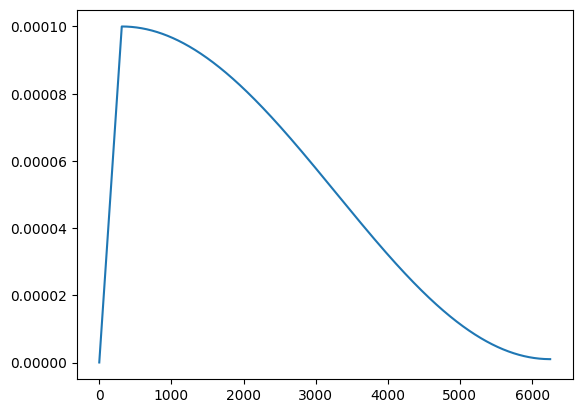

In [31]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

EPOCHS = 4
train_steps = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(train_steps,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,train_steps+1)])

In [32]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS=10,file='saved_weights.pt'):

    global losses
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.BCEWithLogitsLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            x,y = batch
            y = y.float().unsqueeze(1) 
            pred = model(x)
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)

        print(f'Train Loss = {loss}')

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(test):

                x,y = batch
                y = y.float().unsqueeze(1) 
                pred = model(x)
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()

        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('---------------------------------------')
        print()

In [33]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=1,pool_type='avg_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file="avg_pool.pt")

state_dict = torch.load("avg_pool.pt", map_location=device)
model.load_state_dict(state_dict)

1/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.6007
Val Loss = 0.4696
--weights saved
---------------------------------------

2/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.4349
Val Loss = 0.4184
--weights saved
---------------------------------------

3/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.374
Val Loss = 0.4151
--weights saved
---------------------------------------

4/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.3406
Val Loss = 0.4112
--weights saved
---------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     12500
           1       0.81      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000

0.8114623243933589


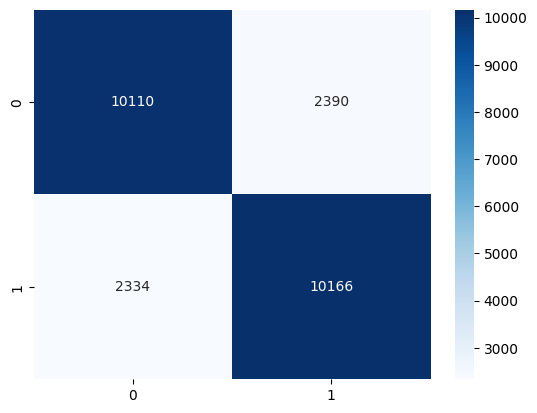

In [34]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x, _ in test:
    pred = model(x)
    pred = torch.sigmoid(pred) 
    pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
    if pred.ndim == 0:
        preds.append(pred.item())
    else:
        preds.extend(pred)

print(classification_report(ytest,preds)) 
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['avg_pool'] = get_metrics_dict(ytest,preds)

In [35]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=1,pool_type='attn_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='attn_pool.pt')

state_dict = torch.load('attn_pool.pt', map_location=device)
model.load_state_dict(state_dict)

1/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.5847
Val Loss = 0.467
--weights saved
---------------------------------------

2/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.4356
Val Loss = 0.4203
--weights saved
---------------------------------------

3/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.3749
Val Loss = 0.4139
--weights saved
---------------------------------------

4/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.3385
Val Loss = 0.4102
--weights saved
---------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.81      0.82      0.81     12500
           1       0.81      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000

0.8139665251861936


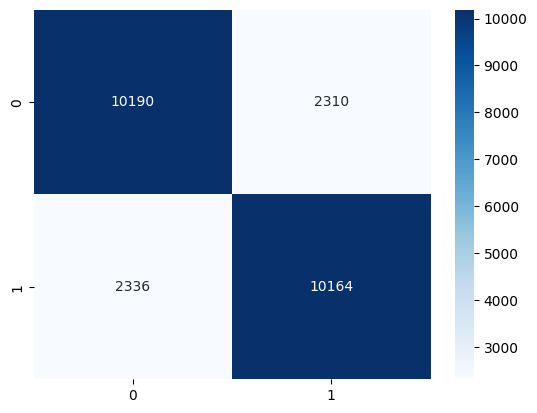

In [36]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x, _ in test:
    pred = model(x)
    pred = torch.sigmoid(pred) 
    pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
    if pred.ndim == 0:
        preds.append(pred.item())
    else:
        preds.extend(pred)

print(classification_report(ytest,preds)) 
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['attn_pool'] = get_metrics_dict(ytest,preds)

In [37]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=1,pool_type='geometric_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='geometric_pool.pt')

state_dict = torch.load('geometric_pool.pt', map_location=device)
model.load_state_dict(state_dict)

1/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.584
Val Loss = 0.4605
--weights saved
---------------------------------------

2/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.4272
Val Loss = 0.413
--weights saved
---------------------------------------

3/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.3628
Val Loss = 0.409
--weights saved
---------------------------------------

4/4


  0%|          | 0/1563 [00:00<?, ?it/s]

Train Loss = 0.3264
Val Loss = 0.4046
--weights saved
---------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.82      0.81      0.82     12500
           1       0.81      0.82      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000

0.8184240881428742


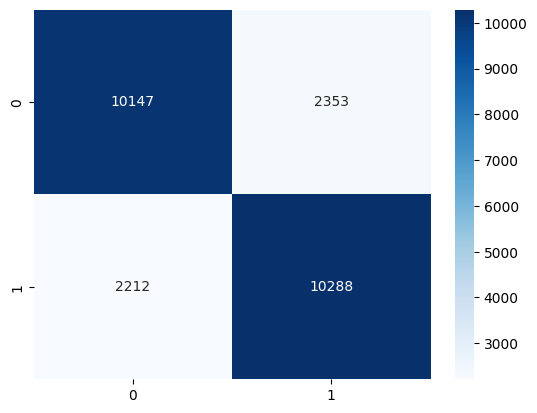

In [38]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x, _ in test:
    pred = model(x)
    pred = torch.sigmoid(pred) 
    pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
    if pred.ndim == 0:
        preds.append(pred.item())
    else:
        preds.extend(pred)

print(classification_report(ytest,preds)) 
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['geometric_pool'] = get_metrics_dict(ytest,preds)

In [39]:
import json


with open("imdb_metrics_.json",'w') as f:
    json.dump(metrics,f)

In [40]:
metrics

{'avg_pool': {'accuracy': 0.81104,
  'precision': 0.8096527556546671,
  'recall': 0.81328,
  'f1': 0.8114623243933589},
 'attn_pool': {'accuracy': 0.81416,
  'precision': 0.8148148148148148,
  'recall': 0.81312,
  'f1': 0.8139665251861936},
 'geometric_pool': {'accuracy': 0.8174,
  'precision': 0.8138596630013448,
  'recall': 0.82304,
  'f1': 0.8184240881428742}}

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


def load_model(pool_type):
    model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                       n_classes=1,pool_type=pool_type)

    model = model.to('cuda')
    state_dict = torch.load(f'{pool_type}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

model0 = load_model('avg_pool')
model1 = load_model('attn_pool')
model2 = load_model('geometric_pool')

def get_pooled_vectors(model,test):
    
    with torch.no_grad():

        vectors = []

        for x, _ in test:
            x = x.to('cuda')
            pool_vec = model(x,return_pool=True)
            pool_vec = pool_vec.cpu().numpy()
            vectors.extend(pool_vec)
        
        vectors = np.array(vectors,dtype=np.float32)
        
        return vectors

reset_random_seeds() 
    
vectors0 = get_pooled_vectors(model0,test)
vectors1 = get_pooled_vectors(model1,test)
vectors2 = get_pooled_vectors(model2,test)


def cluster_eval(embeddings,true_labels,name='',classes=2):
    kmeans = KMeans(n_clusters=classes, n_init=10, random_state=42)
    cluster_preds = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(true_labels, cluster_preds)
    print(f"Clustering ARI against True Sentiment: {ari:.4f} ({name})")
    return ari,name

cluster_eval_metrics = {}

ari,name = cluster_eval(vectors0,ytest,'avg_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors1,ytest,'attn_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors2,ytest,'geometric_pool')
cluster_eval_metrics[name] = ari

with open("imdb_cluster_metrics_.json",'w') as f:
    json.dump(cluster_eval_metrics,f)

Clustering ARI against True Sentiment: 0.3811 (avg_pool)
Clustering ARI against True Sentiment: 0.3879 (attn_pool)
Clustering ARI against True Sentiment: 0.3948 (geometric_pool)
